# Basic Statistics Assignment
Descriptive Analytics and Data Preprocessing on Sales & Discounts Dataset

In [7]:
pip install scikit-learn


   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 3.3 MB/s eta 0:00:03
   ------ --------------------------------- 1.3/8.1 MB 4.0 MB/s eta 0:00:02
   ---------- ----------------------------- 2.1/8.1 MB 3.9 MB/s eta 0:00:02
   ------------------ --------------------- 3.7/8.1 MB 4.7 MB/s eta 0:00:01
   ------------------------ --------------- 5.0/8.1 MB 5.2 MB/s eta 0:00:01
   ------------------------------- -------- 6.3/8.1 MB 5.4 MB/s eta 0:00:01
   ------------------------------------- -- 7.6/8.1 MB 5.8 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 5.6 MB/s  0:00:01
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   -- ------------------------------------- 2.6/37.3 MB 13.5 MB/s eta 0:00:03
   ----- ---------------------------------- 5.0/37.3 MB 12.6 MB/s eta 0:00:03
   --------- ------------------------------ 8.9/37.3 MB 15.4 MB/s eta 0:00:02
   ----------- -------

In [9]:

# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler


In [12]:

# Load Dataset
df = pd.read_csv("sales_data_with_discounts.csv")

# Display Dataset
print("First 5 Rows of Dataset")
df.head()


First 5 Rows of Dataset


,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843
3,01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298
4,01-04-2021,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770


In [13]:

# Identify Numerical and Categorical Columns
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)


Numerical Columns: ['Volume', 'Avg Price', 'Total Sales Value', 'Discount Rate (%)', 'Discount Amount', 'Net Sales Value']
Categorical Columns: ['Date', 'Day', 'SKU', 'City', 'BU', 'Brand', 'Model']


In [14]:

# Descriptive Analytics
for col in num_cols:
    print(f"\nColumn: {col}")
    print("Mean:", df[col].mean())
    print("Median:", df[col].median())
    print("Mode:", df[col].mode()[0])
    print("Standard Deviation:", df[col].std())



Column: Volume
Mean: 5.066666666666666
Median: 4.0
Mode: 3
Standard Deviation: 4.231602391213923

Column: Avg Price
Mean: 10453.433333333332
Median: 1450.0
Mode: 400
Standard Deviation: 18079.90483993647

Column: Total Sales Value
Mean: 33812.83555555555
Median: 5700.0
Mode: 24300
Standard Deviation: 50535.07417255325

Column: Discount Rate (%)
Mean: 15.155241895330914
Median: 16.57776564929597
Mode: 5.007822189204133
Standard Deviation: 4.22060215332551

Column: Discount Amount
Mean: 3346.499424342415
Median: 988.9337332382784
Mode: 69.17794228822787
Standard Deviation: 4509.902963353998

Column: Net Sales Value
Mean: 30466.336131270138
Median: 4677.788059301853
Mode: 326.97480055470817
Standard Deviation: 46358.65662406695


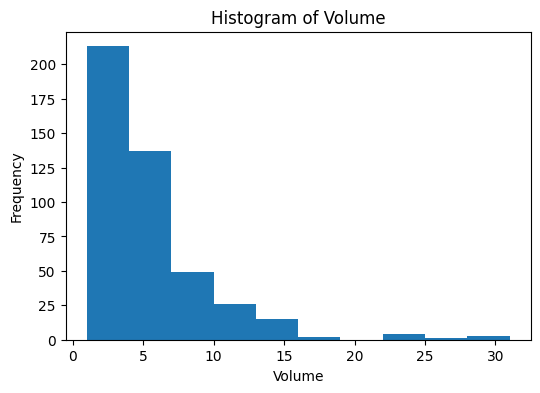

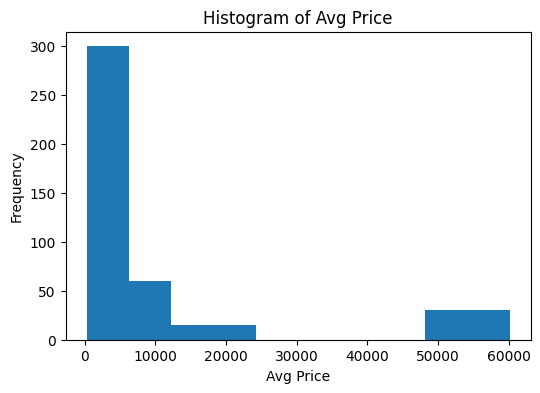

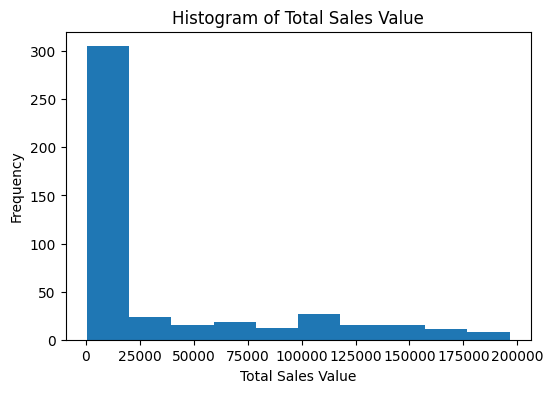

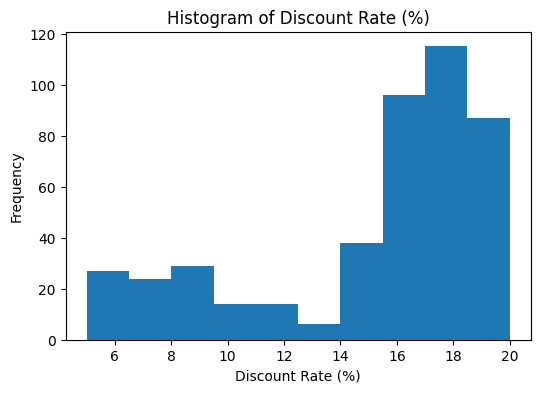

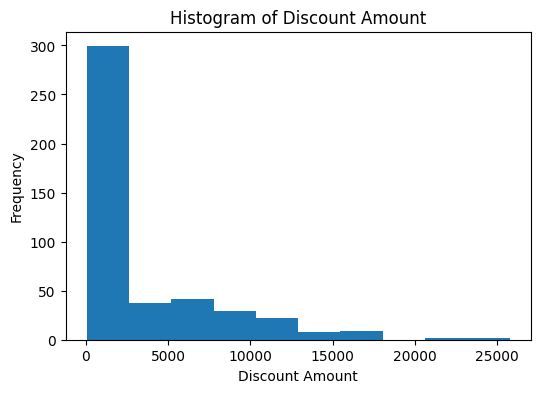

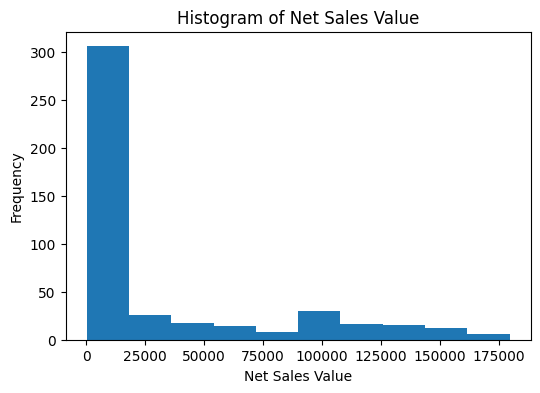

In [15]:

# Histograms
for col in num_cols:
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=10)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


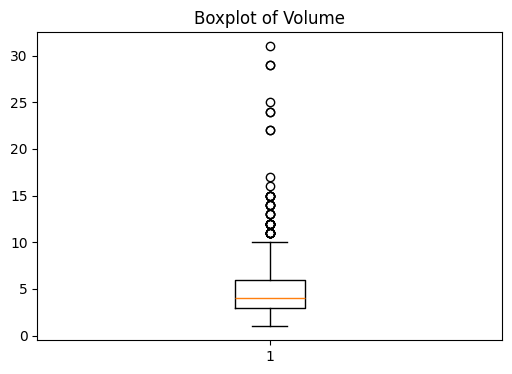

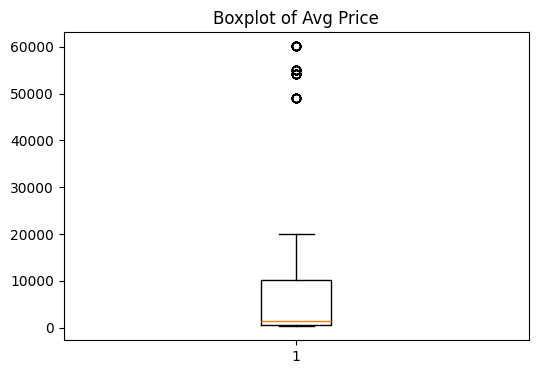

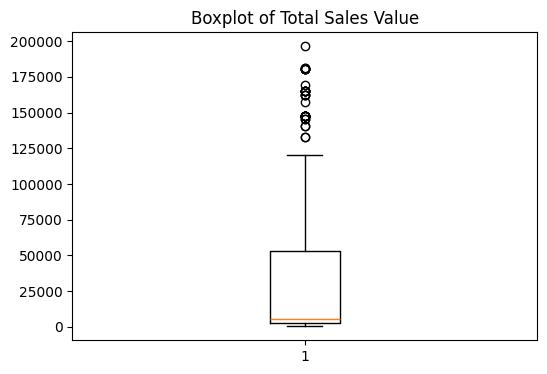

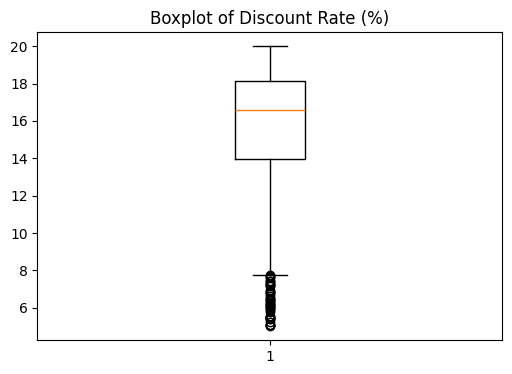

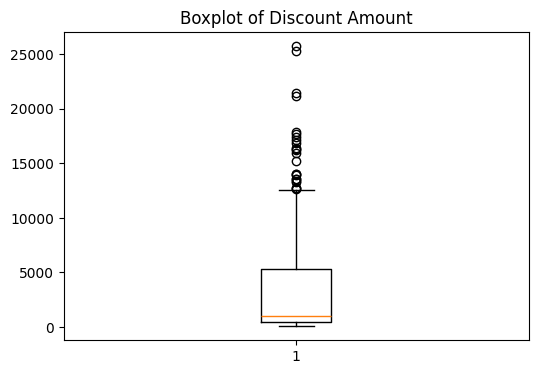

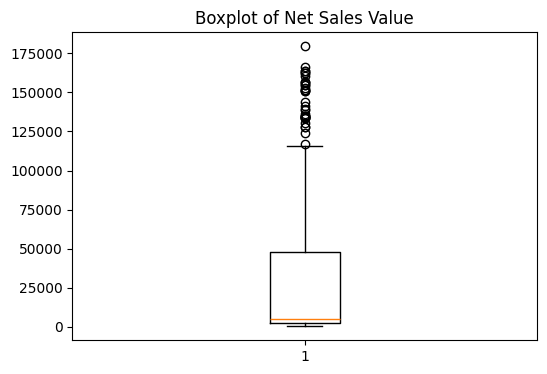

In [16]:

# Boxplots
for col in num_cols:
    plt.figure(figsize=(6,4))
    plt.boxplot(df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


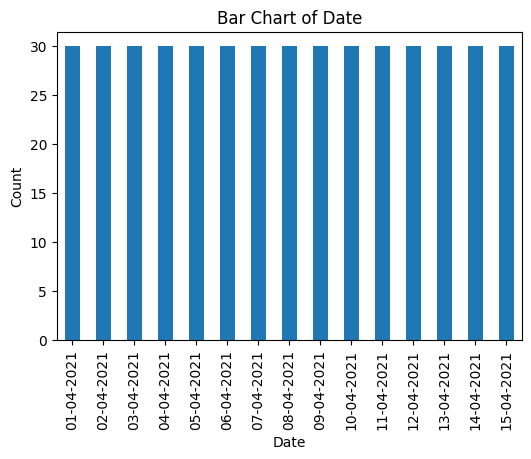

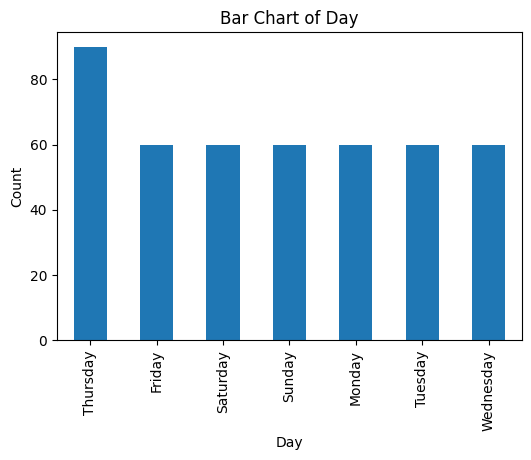

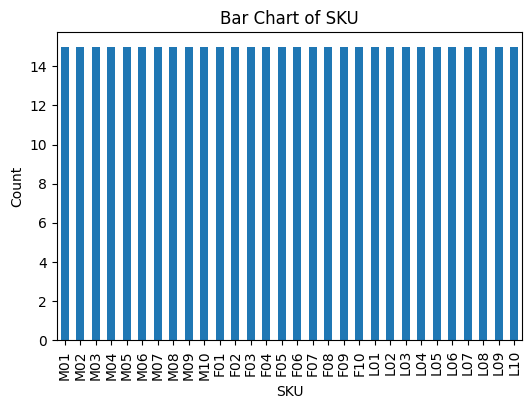

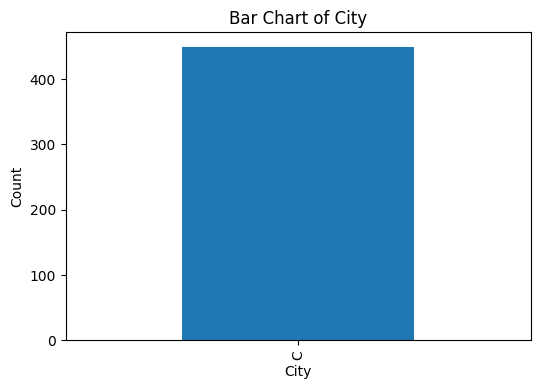

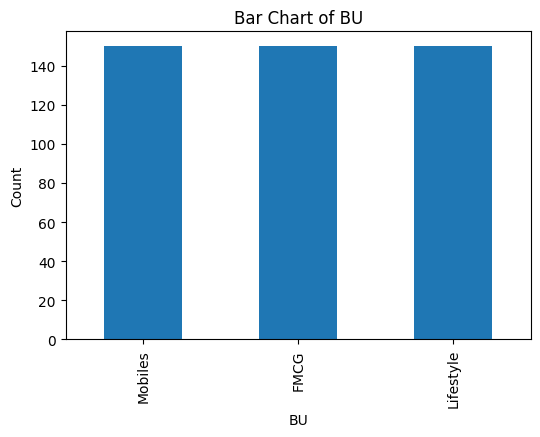

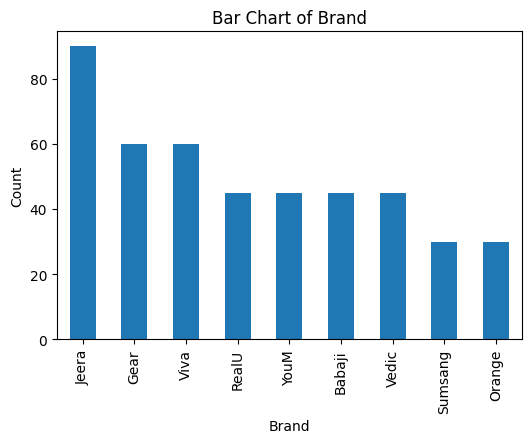

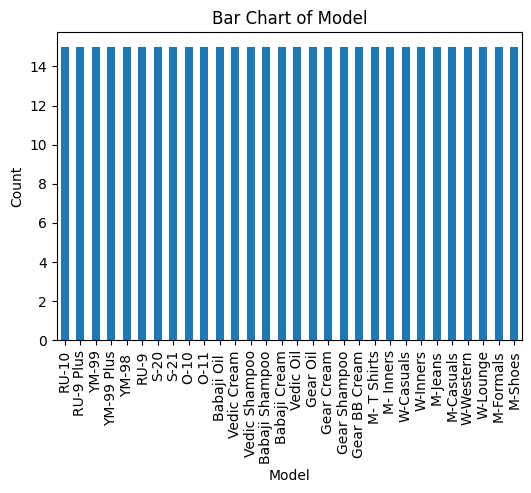

In [17]:

# Bar Charts for Categorical Columns
for col in cat_cols:
    plt.figure(figsize=(6,4))
    df[col].value_counts().plot(kind='bar')
    plt.title(f"Bar Chart of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()


In [18]:

# Standardization
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df[num_cols])

scaled_df = pd.DataFrame(scaled_data, columns=num_cols)

print("Before Standardization")
print(df[num_cols].head())

print("\nAfter Standardization")
print(scaled_df.head())


Before Standardization
   Volume  Avg Price  Total Sales Value  Discount Rate (%)  Discount Amount  \
0      15      12100             181500          11.654820     21153.498820   
1      10      10100             101000          11.560498     11676.102961   
2       7      16100             112700           9.456886     10657.910157   
3       6      20100             120600           6.935385      8364.074702   
4       3       8100              24300          17.995663      4372.946230   

   Net Sales Value  
0    160346.501180  
1     89323.897039  
2    102042.089843  
3    112235.925298  
4     19927.053770  

After Standardization
     Volume  Avg Price  Total Sales Value  Discount Rate (%)  Discount Amount  \
0  2.350029   0.091173           2.925721          -0.830289         3.952816   
1  1.167129  -0.019570           1.330995          -0.852661         1.849014   
2  0.457388   0.312659           1.562775          -1.351631         1.622995   
3  0.220808   0.534146       

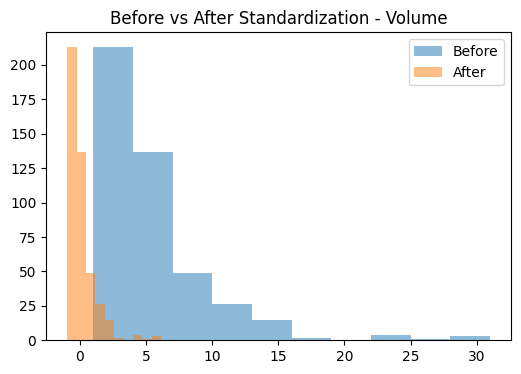

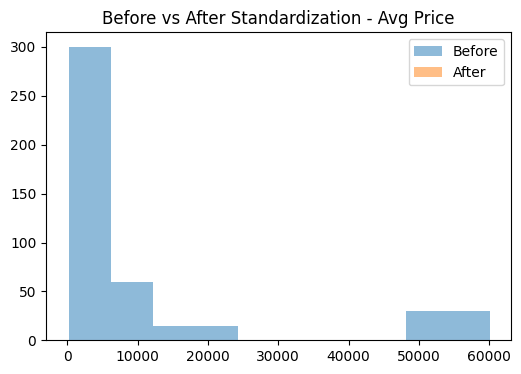

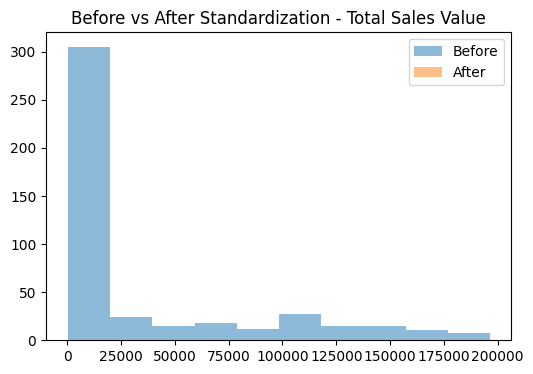

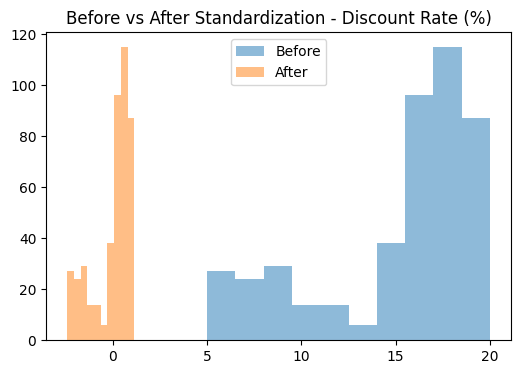

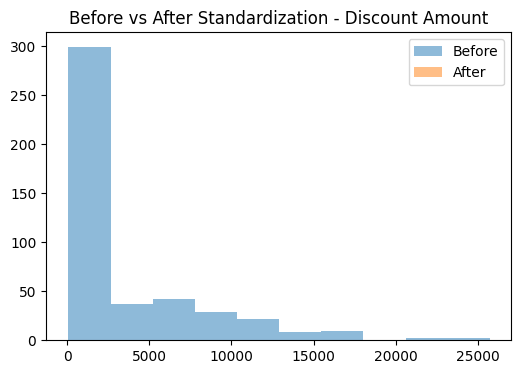

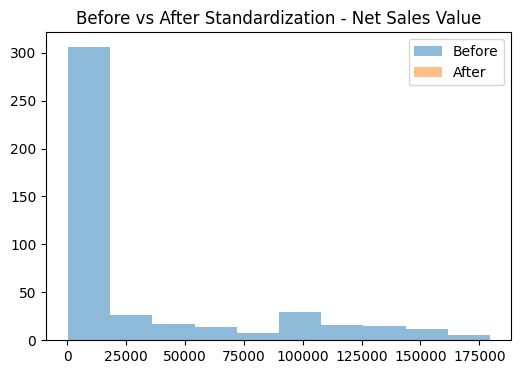

In [19]:

# Before vs After Standardization Plots
for col in num_cols:
    plt.figure(figsize=(6,4))
    plt.hist(df[col], alpha=0.5, label="Before")
    plt.hist(scaled_df[col], alpha=0.5, label="After")
    plt.title(f"Before vs After Standardization - {col}")
    plt.legend()
    plt.show()


In [20]:

# One-Hot Encoding
dummy_df = pd.get_dummies(df, columns=cat_cols)

print("Transformed Dataset")
dummy_df.head()


Transformed Dataset


,Volume,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value,Date_01-04-2021,Date_02-04-2021,Date_03-04-2021,Date_04-04-2021,...,Model_Vedic Cream,Model_Vedic Oil,Model_Vedic Shampoo,Model_W-Casuals,Model_W-Inners,Model_W-Lounge,Model_W-Western,Model_YM-98,Model_YM-99,Model_YM-99 Plus
0,15,12100,181500,11.654820,21153.498820,160346.501180,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,10,10100,101000,11.560498,11676.102961,89323.897039,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,7,16100,112700,9.456886,10657.910157,102042.089843,True,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,6,20100,120600,6.935385,8364.074702,112235.925298,True,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,3,8100,24300,17.995663,4372.946230,19927.053770,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False



# Conclusion

1. Descriptive analytics helped understand the dataset.
2. Histograms and boxplots identified distributions and outliers.
3. Standardization normalized numerical values.
4. One-hot encoding converted categorical data into machine-learning-ready format.
